# Time-Series Modelling

In [30]:
%load_ext pretty_jupyter 

The pretty_jupyter extension is already loaded. To reload it, use:
  %reload_ext pretty_jupyter


## Introduction

In this section, you will learn how to handle time-series data using Python. We'll explore various techniques for identifying key characteristics of time-series data, such as trends, seasonality, and autocorrelation. Additionally, you will learn how to implement basic time-series modeling approaches to make forecasts.

# Packages and codes used

In this Python workthrough, we will use and import the following libraries:

In [38]:
!pip install statsmodels stargazer
import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical computations
import matplotlib.pyplot as plt  # For basic plotting
from lets_plot import *  # For advanced and interactive plots
from statsmodels.api import OLS, add_constant  # For regression modeling
from statsmodels.stats.sandwich_covariance import cov_hac, cov_white_simple  # For robust standard errors
from statsmodels.tsa.stattools import adfuller  # For Augmented Dickey-Fuller tests
from stargazer.stargazer import Stargazer  # For creating formatted regression tables
import requests  # For making HTTP requests to web servers for data retrieval
from io import StringIO  # For creating in-memory text streams which behave like files


| Library/Function                                | Description |
|-------------------------------------------------|-------------|
| `pandas`                                        | Used for handling and manipulating datasets in tabular format. |
| `numpy`                                         | Provides efficient numerical operations, including array manipulations and mathematical functions. |
| `matplotlib.pyplot`                             | A basic plotting library for visualizing data. |
| `lets_plot`                                     | Inspired by R's ggplot2, it allows creating advanced and interactive plots directly within Python. |
| `statsmodels.api`                               | Provides a framework for statistical modeling, including Ordinary Least Squares (OLS) regression. |
| `statsmodels.stats.sandwich_covariance`         | Contains methods for computing robust standard errors. |
| - `cov_hac`                                     | Computes Newey-West standard errors for heteroskedasticity and autocorrelation corrections. |
| - `cov_white_simple`                            | Computes White’s robust standard errors for heteroskedasticity correction. |
| `statsmodels.tsa.stattools`                     | Contains functions for time series analysis. |
| - `adfuller`                                    | Performs the Augmented Dickey-Fuller test to check for stationarity in time series data. |
| `stargazer.stargazer`                           | A package to create formatted regression tables for use in reports, papers, and presentations. |
| `requests`                                      | Used to make HTTP requests to download data from the web. |
| `from io import StringIO`                       | Used for handling text I/O operations, enabling the manipulation of string data as if it were a file. |


In the R walkthrough, two custom functions ([stargazer_HC.R](https://github.com/datasquad/ECLR/blob/gh-pages/docs/stargazer_HC.R) and [stargazer_HAC.R](https://github.com/datasquad/ECLR/blob/gh-pages/docs/stargazer_HAC.R)) were sourced from external .r files. For the Python equivalent, you can find these functions available to download from here: [stargazer_HC.py](https://github.com/SimoKF/Drafting-Python-resources-for-ECLR/blob/main/stargazer_hc.ipynb) and [stargazer_HAC.py](https://github.com/SimoKF/Drafting-Python-resources-for-ECLR/blob/main/stargazer_hac.ipynb).

When you get to that page, you will see a download button.

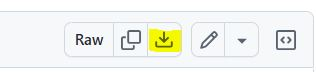

For the Python equivalent, the functions `stargazer_HC.py` and `stargazer_HAC.py` can be downloaded and saved into your working directory. Once downloaded, you can make these functions available to your code using the following lines:

In [ ]:
from stargazer_HC import stargazer_HC  # Includes the robust regression display
from stargazer_HAC import stargazer_HAC  # Includes the Newey-West standard errors

# A single time series
## Import data

We shall use some data from the Office for National Statistics (ONS) in the UK. In Python, we do not have a direct equivalent to R's `pdfetch_ONS` function. However, you can achieve the same result using the following steps:

- **Obtain the Data Manually or via an API**: Use the [ONS Time Series Tool](https://www.ons.gov.uk/timeseriestool) to locate and download the data. For example, search for the `AMBI` series in the `UKEA` databank.
- **Process the Data in Python**: After downloading the dataset as a CSV file, you can use `pandas` to load and analyze the data.

When you get data from the ONS, you need to know the series ID and which ONS dataset you can find. To find that info, go to the [ONS time series tool](https://www.ons.gov.uk/timeseriestool). You can find more details on how to use this tool [here](https://datasquad.github.io/ECLR/R_DataDownload.html).


For instance we can get real GDP data (id: AMBI) from the UKEA databank. Once we have downloaded the data from the [ONS Time Series Tool](https://www.ons.gov.uk/timeseriestool) we notice that the dates are stored in rows rather than as a proper column. In this case it is important to:

1. **Identify the structure of the CSV file**: From the .csv file, the actual data starts after several metadata rows (e.g., "Title," "CDID").
2. **Skip the metadata rows**: Use the `skiprows` parameter in `pd.read_csv()` to skip these rows and directly access the main data.
3. **Set the correct column names**: From the .csv file, the first column contains the years, and the second column contains the GDP values.

Moreover, we can also indicate that the dataset includes annual data until a certain point, after which it switches to quarterly data.

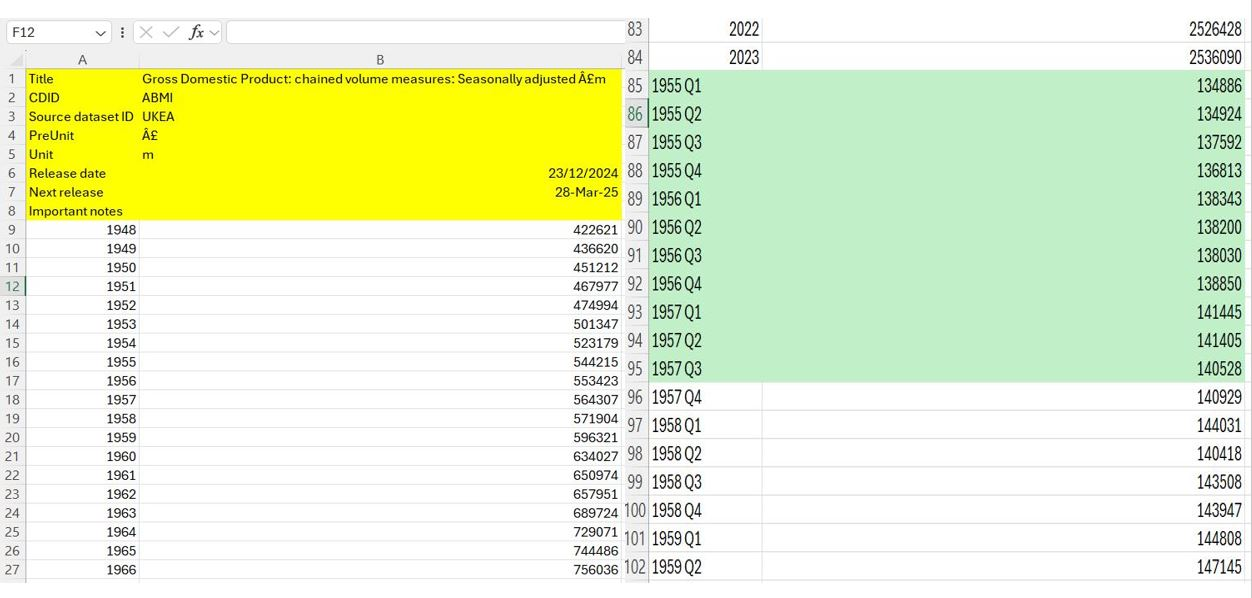

Let's say that you want to load and process **yearly data** (1948 to 2023)

In [67]:
# URL of the dataset
url = "https://www.ons.gov.uk/generator?format=csv&uri=/economy/grossdomesticproductgdp/timeseries/abmi/ukea"

# Fetch the dataset using requests
response = requests.get(url)

if response.status_code == 200:
    print("Dataset fetched successfully for Yearly data.")
    
    # Load yearly data while skipping metadata rows
    csv_data_yearly = StringIO(response.text)
    yearly_data = pd.read_csv(csv_data_yearly, skiprows=8, nrows=76, names=['Year', 'Real GDP'])

    # Convert 'Year' to datetime, setting year-end as date
    yearly_data['Year'] = pd.to_datetime(yearly_data['Year'].astype(str) + '-12-31')

    # Set 'Year' as the index
    yearly_data.set_index('Year', inplace=True)

    # For display purposes: Show only the year part of the index
    display_data = yearly_data.copy()
    display_data.index = display_data.index.year

    print("\nYearly Dataset:")
    print(display_data.head())
else:
    print(f"Failed to fetch dataset for Yearly data. HTTP Status Code: {response.status_code}")


Dataset fetched successfully for Yearly data.

Yearly Dataset:
      Real GDP
Year          
1948    422621
1949    436620
1950    451212
1951    467977
1952    474994


Here we are able to fetche yearly Real GDP data from the UK Office for National Statistics (ONS) using an API endpoint. We use the `requests` library to retrieve the data in CSV format and `pandas` to process and structure it. The script skips metadata rows and loads only the yearly data (from 1948 to 2023) using the `skiprows` and `nrows` parameters. The "Year" column is converted to a datetime format, setting each date to the end of the year (December 31), and this column is set as the index. A copy of the data is created for display purposes, where only the year is shown as an integer (without including the day and month). If the data fetch is successful, the script displays the first few rows of the cleaned dataset; otherwise, it reports the HTTP error. This code ensures the data is structured as a time series for further analysis.

On the contrary, lets' assume that now you want to load and process **quarterly data** ( 1955 Q1 to 2024 Q3).

In [527]:
import pandas as pd
import requests
from io import StringIO

# URL of the dataset
url = "https://www.ons.gov.uk/generator?format=csv&uri=/economy/grossdomesticproductgdp/timeseries/abmi/ukea"

# Fetch the dataset using requests
response = requests.get(url)

if response.status_code == 200:
    print("Dataset fetched successfully for Quarterly data.")
    
    # Load quarterly data while skipping the rows for yearly data
    csv_data_quarterly = StringIO(response.text)
    quarterly_data = pd.read_csv(csv_data_quarterly, skiprows=84, nrows=279, names=['Quarter', 'Real GDP'])

    # Replace 'Q1', 'Q2', etc., with corresponding end-of-quarter dates
    quarterly_data['Quarter'] = quarterly_data['Quarter'].str.replace(
        r' Q1', '-03-31').str.replace(
        r' Q2', '-06-30').str.replace(
        r' Q3', '-09-30').str.replace(
        r' Q4', '-12-31')

    # Convert 'Quarter' to datetime format
    quarterly_data['Quarter'] = pd.to_datetime(quarterly_data['Quarter'], format='%Y-%m-%d', errors='coerce')

    # Check for rows with NaT
    if quarterly_data['Quarter'].isna().any():
        print("There are rows with invalid dates. Please check the input data format.")

    # Previously 'set_index' was setting 'Quarter' as the index. Removing this will keep 'Quarter' as a column.
    # quarterly_data.set_index('Quarter', inplace=True)  # Remove this line to keep 'Quarter' as a regular column.

    print("\nQuarterly Dataset:")
    print(quarterly_data.head())
else:
    print(f"Failed to fetch dataset for Quarterly data. HTTP Status Code: {response.status_code}")


Dataset fetched successfully for Quarterly data.

Quarterly Dataset:
     Quarter  Real GDP
0 1955-03-31    134886
1 1955-06-30    134924
2 1955-09-30    137592
3 1955-12-31    136813
4 1956-03-31    138343


By running this code we are able to skip metadata and yearly data rows (`skiprows=84`) and load only the quarterly data (`nrows=279`). The "Quarter" column, initially in a `YYYY QX` format, is transformed into end-of-quarter dates (`YYYY-MM-DD`) using string replacements. The transformed dates are then converted into datetime objects for time-series compatibility. The code checks for invalid date conversions (`NaT`) and sets the "Quarter" column as the DataFrame index. Finally, the first few rows of the processed data are displayed, ensuring that the dataset is ready for further analysis or visualization. If the dataset fails to load, an HTTP error code is displayed.

## Time Series Plots

With `lets-plot` in Python, you can easily visualize data series with a syntax that is intuitive and flexible. This library provides a clear, concise way to describe the visual representation of data, focusing on the aesthetics and relationships you want to highlight. Whether you're plotting simple line graphs or complex multi-layered visualizations, `lets-plot` enables a straightforward approach to plotting by allowing you to layer components with simple commands. This method is particularly useful for exploratory data analysis where visual consistency and readability are key.

Let's plot the **quarterly** data

In [485]:
# Simplify data structure by creating a plain DataFrame
quarterly_data_reset = quarterly_data.reset_index()
quarterly_data_reset['Quarter'] = quarterly_data_reset['Quarter'].dt.strftime('%Y-%m-%d')  # Ensure plain string format

# Prepare the dataset for plotting
data = {'Date': quarterly_data_reset['Quarter'], 'Real GDP': quarterly_data_reset['Real GDP']}

# Try plotting with simplified data and no custom axis formatting
plot = ggplot(data, aes(x='Date', y='Real GDP')) + \
    geom_line(color='black', size=1) + \
    ggtitle('Real GDP Over Time') + \
    xlab('Quarter') + \
    ylab('Real GDP')

# Display the plot
plot.show()


Let's now plot the **annual** dataset:

In [487]:
# Assuming 'yearly_data' is already loaded and prepared as described
# Convert DataFrame index to a column for plotting and ensure Year is integer
yearly_data_reset = yearly_data.reset_index()
yearly_data_reset['Year'] = yearly_data_reset['Year'].dt.year.astype(str)  # Convert Year to string

# Create a dictionary for lets-plot
data = {'Year': yearly_data_reset['Year'], 'Real GDP': yearly_data_reset['Real GDP']}

# Create the plot
plot = ggplot(data, aes('Year', 'Real GDP')) + \
    geom_line(color='darkblue', size=1.5) + \
    ggtitle('Yearly Real GDP Over Time') + \
    xlab('Year') + \
    ylab('Real GDP (£m)') + \
    theme_minimal() + \
    scale_x_discrete()  # This ensures the x-axis treats years as discrete labels, not continuous numbers

# Display the plot
plot.show()


To demonstrate the power of time series plotting in Python, using `matplotlib` can serve as a robust alternative to other libraries like `lets-plot`. While `lets-plot` is a great tool for creating ggplot-like visualizations in Python, `matplotlib` excels in terms of flexibility, stability, and compatibility with various data formats.

In [489]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming `quarterly_data` and `yearly_data` are already loaded

# Restructure Quarterly Data
quarterly_data_reset = quarterly_data.reset_index()
quarterly_data_reset.rename(columns={'Quarter': 'Date', 'Real GDP': 'Value'}, inplace=True)
quarterly_data_reset['id'] = 'Quarterly'

# Restructure Yearly Data
yearly_data_reset = yearly_data.reset_index()
yearly_data_reset.rename(columns={'Year': 'Date', 'Real GDP': 'Value'}, inplace=True)
yearly_data_reset['id'] = 'Yearly'

# Combine both datasets
combined_data = pd.concat([quarterly_data_reset, yearly_data_reset])


By running this code we are essentially preparing the **quarterly** and **yearly** Real GDP data for visualization by restructuring the datasets into a "long format," which is essential for time series plotting. Specifically:

- it resets the indices (`Quarter` and `Year`) to convert them into regular columns (`Date`),
- standardizes the column names (`Real GDP` to `Value`), and
- adds an `id` column to differentiate between quarterly and yearly data.

Finally, the two datasets are combined into a single DataFrame (`combined_data`) for unified analysis or plotting. This restructuring is crucial because it aligns the data consistently, making it easier to create individual or comparative time series plots using visualization libraries like` matplotlib`.

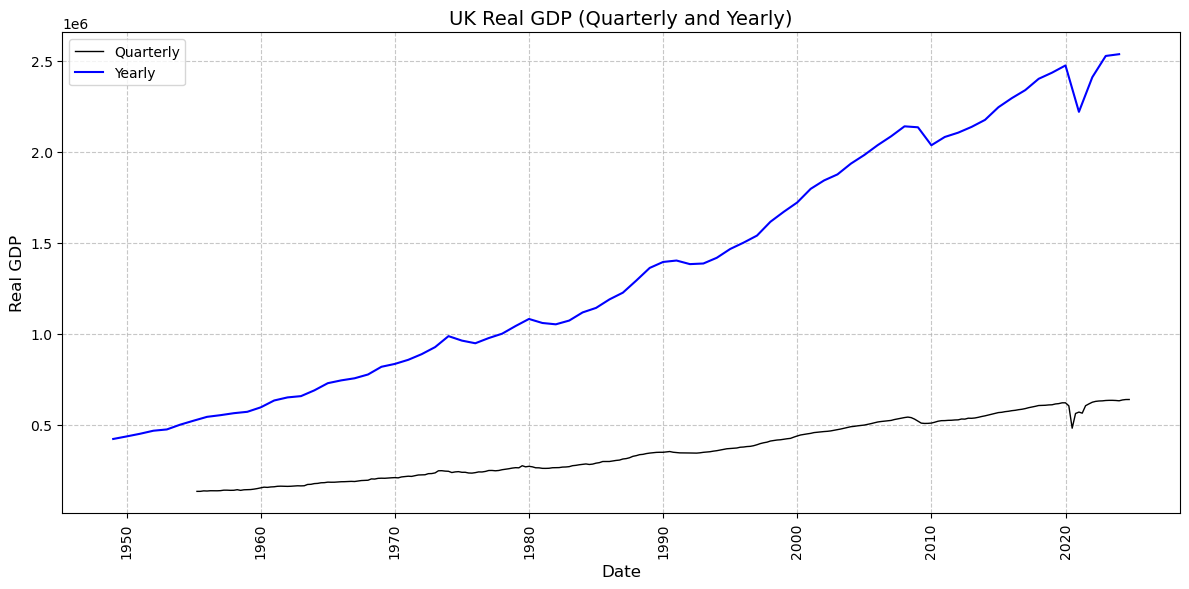

In [491]:
# Plot Combined Data
plt.figure(figsize=(12, 6))

# Quarterly Data
plt.plot(quarterly_data_reset['Date'], quarterly_data_reset['Value'], color='black', linewidth=1, label='Quarterly')

# Yearly Data
plt.plot(yearly_data_reset['Date'], yearly_data_reset['Value'], color='blue', linewidth=1.5, label='Yearly')

plt.title('UK Real GDP (Quarterly and Yearly)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Real GDP', fontsize=12)
plt.xticks(rotation=90)  # Rotate x-axis labels
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In Python, using `lets-plot`, you can achieve the same functionality as the **subset** function in R by filtering the DataFrame directly using Pandas before passing it into the plotting function. This allows you to plot a specific subset of your data, such as filtering rows where `Year` is after "2000".

[//]: # (-.- .tabset)

##### Step 1: Load, Prepare and Subset Yearly Data

In [493]:
# URL of the dataset
url = "https://www.ons.gov.uk/generator?format=csv&uri=/economy/grossdomesticproductgdp/timeseries/abmi/ukea"

# Fetch the dataset using requests
response = requests.get(url)

if response.status_code == 200:
    print("Dataset fetched successfully for Yearly data.")
    
    # Load yearly data while skipping metadata rows
    csv_data_yearly = StringIO(response.text)
    yearly_data = pd.read_csv(csv_data_yearly, skiprows=8, nrows=76, names=['Year', 'Real GDP'])

    # Convert 'Year' to datetime, setting year-end as date
    yearly_data['Year'] = pd.to_datetime(yearly_data['Year'].astype(str) + '-12-31')

    # Set 'Year' as the index
    yearly_data.set_index('Year', inplace=True)

    # Reset the index to make 'Year' a column again and format as year only
    yearly_data_reset = yearly_data.reset_index()
    yearly_data_reset['Year'] = yearly_data_reset['Year'].dt.year  # Format 'Year' to show year part only

    # Filter data for the subset after 2000
    filtered_yearly_data = yearly_data_reset[yearly_data_reset['Year'] > 2000]

    # Display a snippet of the dataset
    print("\nFiltered Yearly Dataset (Post-2000):")
    print(filtered_yearly_data.head())
else:
    print(f"Failed to fetch dataset for Yearly data. HTTP Status Code: {response.status_code}")


Dataset fetched successfully for Yearly data.

Filtered Yearly Dataset (Post-2000):
    Year  Real GDP
53  2001   1842720
54  2002   1875809
55  2003   1934941
56  2004   1982500
57  2005   2036675


The `filtered_yearly_data = yearly_data_reset[yearly_data_reset['Year'] > '2000']` line filters`yearly_data_reset` to include only the rows where 'Year' is greater than "2000". This comparison is string-based due to the previous conversion of 'Year' to a string format. The resulting `filtered_yearly_data` DataFrame contains only entries from 2001 onwards.


##### Step 2: Plot the series using `lets-plot`

In [852]:
from lets_plot import *
LetsPlot.setup_html()

# Explicitly create a copy to avoid SettingWithCopyWarning
filtered_yearly_data = filtered_yearly_data.copy()

# Convert 'Year' column to string
filtered_yearly_data['Year'] = filtered_yearly_data['Year'].astype(str)

# Create the plot using the filtered data
plot_yearly = ggplot(filtered_yearly_data, aes(x='Year', y='Real GDP')) + \
    geom_line(color='blue', size=1.5) + \
    ggtitle("UK Real GDP (Yearly Data from 2001 Onwards)") + \
    xlab("Year") + \
    ylab("Real GDP (£m)") + \
    theme_minimal() + \
    theme(axis_text_x=element_text(angle=45, hjust=1)) + \
    scale_x_discrete(labels=filtered_yearly_data['Year'].tolist())  # Correctly formatted string labels

# Display the plot
plot_yearly.show()


We can use the `lets-plot` library to create and display a line plot of the UK's Real GDP from the year 2001 onwards. More specifically:

1. **Setup**: Initializes the `lets-plot` environment to enable HTML output for visualizations within a Jupyter notebook or a web-based interface.
2. **Data Preparation**: Ensures the 'Year' column in the `filtered_yearly_data` DataFrame is formatted as a string. This step is crucial for correctly displaying the x-axis labels in the plot, as `lets-plot` requires labels to be in string format for custom text manipulation.


[//]: # (-.- .unlisted .unnumbered)

# Autocorrelation Function (ACF)

Let's compute the autocorrelation function (ACF). The ACF describes the relationship between a time series $y_t$ and its own past values lagged by $k$ periods, expressed as $\text{corr}(y_t, y_{t-k})$, for various values of $k$. To calculate and plot the Autocorrelation Function (ACF) in Python, we typically use the statsmodels library, which provides comprehensive statistical functions, including autocorrelation and partial autocorrelation functions. Specifically, you can use the `acf` function from the `statsmodels.tsa.stattools` module to compute the autocorrelation function for a given time series. This function quantifies how much a series is influenced by its previous values, providing insights into the temporal dependencies within the data.


In [198]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf
# Calculate the autocorrelation function up to 20 lags
acf_values = acf(filtered_yearly_data['Real GDP'], nlags=20, fft=True)

The `acf_values` variable now contains the autocorrelation coefficients. Let's now use `lets-plot`to create the ACF plot. To plot the autocorrelation function you've calculated with `lets-plot` in Python, you'll need to first create a DataFrame from the autocorrelation values and then plot it. Let's walk through these steps:

[//]: # (-.- .tabset)

##### Step 1: Create a DataFrame for ACF Values

First, you'll need to organize the autocorrelation values into a pandas DataFrame to make them compatible with lets-plot. This involves setting up a DataFrame with lags as one column and the autocorrelation coefficients as another:

In [203]:
import pandas as pd
from lets_plot import *

# Create a DataFrame from the ACF values
acf_df = pd.DataFrame({
    'Lags': range(len(acf_values)),  # Creating a range for Lags based on the length of acf_values
    'ACF': acf_values                # Autocorrelation values
})


##### Step 2: Plotting with lets-plot

Now you can use lets-plot to visualize these autocorrelation values. Here’s how you can plot them:

In [208]:
from lets_plot import *

# Assuming acf_df is prepared as previously described
ggplot(acf_df, aes(x='Lags', y='ACF')) + \
    geom_bar(stat='identity', fill='blue', color='black', width=0.7) + \
    geom_hline(yintercept=0, color="red", linetype="dotted") + \
    ggtitle("Autocorrelation Function (ACF) for Yearly GDP") + \
    xlab("Lags (years)") + \
    ylab("Autocorrelation Coefficient") + \
    theme_minimal()


From the autocorrelation plot we can observe the following:

1. **First Value at Lag 0**:
The autocorrelation function always begins with a value of 1 at lag 0, indicating that any time series is perfectly correlated with itself without any delay. Mathematically, this is expressed as $ \text{corr}(y_t, y_t) = 1 $.

2.  **Representation in the Plot** :
The plot, as described, starts with the autocorrelation coefficient at lag 0 set to 1 and continues to higher lags. It likely depicts a decreasing trend in the autocorrelation of Yearly GDP data as the lags increase, a common phenomenon observed in economic time series analyses.

3. **Interpretation of Higher Lags**:
With increasing lags, the autocorrelation coefficients generally diminish, suggesting that the influence of past values on current observations decreases as the time gap between them widens. The described plot appears to capture this gradual decay in autocorrelation, which may stabilize or turn negative, reflecting varied patterns of temporal relationships within the data.


[//]: # (-.- .unlisted .unnumbered)

# Multiple time series

Often we will deal with multiple time-series. Now you will learn how to deal with multiple series, store the data, plot them and calculate ACFs. When dealing with multiple time series in Python, you'll often need to download, manipulate, and analyze data from different sources. Let's go through the process using Python tools:

1. **Downloading Data**: We can retrieve data such as female unemployment rates and monthly inflation rates from online sources, like the [ONS database](https://www.ons.gov.uk/timeseriestool). This can be done using libraries like `requests` for web scraping or APIs, or `pandas_datareader` if the data source is supported.

2. **Data Preparation**: Once downloaded, the data typically needs to be formatted into a structure conducive to analysis. In Python, this often means transforming the data into a long format using `pandas`, which makes it easier to handle multiple time series in a unified way.

We download female unemployment (`series ID:YCPL` and `ONS dataset: LMS`)  and monthly inflation rates (`series ID: D7OE` and `ONS dataset:MM23`) from the [ONS database](https://www.ons.gov.uk/timeseriestool). On both occasions, we put the data in a long format.

[//]: # (-.- .tabset)

##### Female unemployment rate ( YCPL in database LMS)

By downloading the female unemployment `.csv datafile`, we can see that the dataset includes annual data until a certain point, after which it switches to quarterly data and then monthly data.

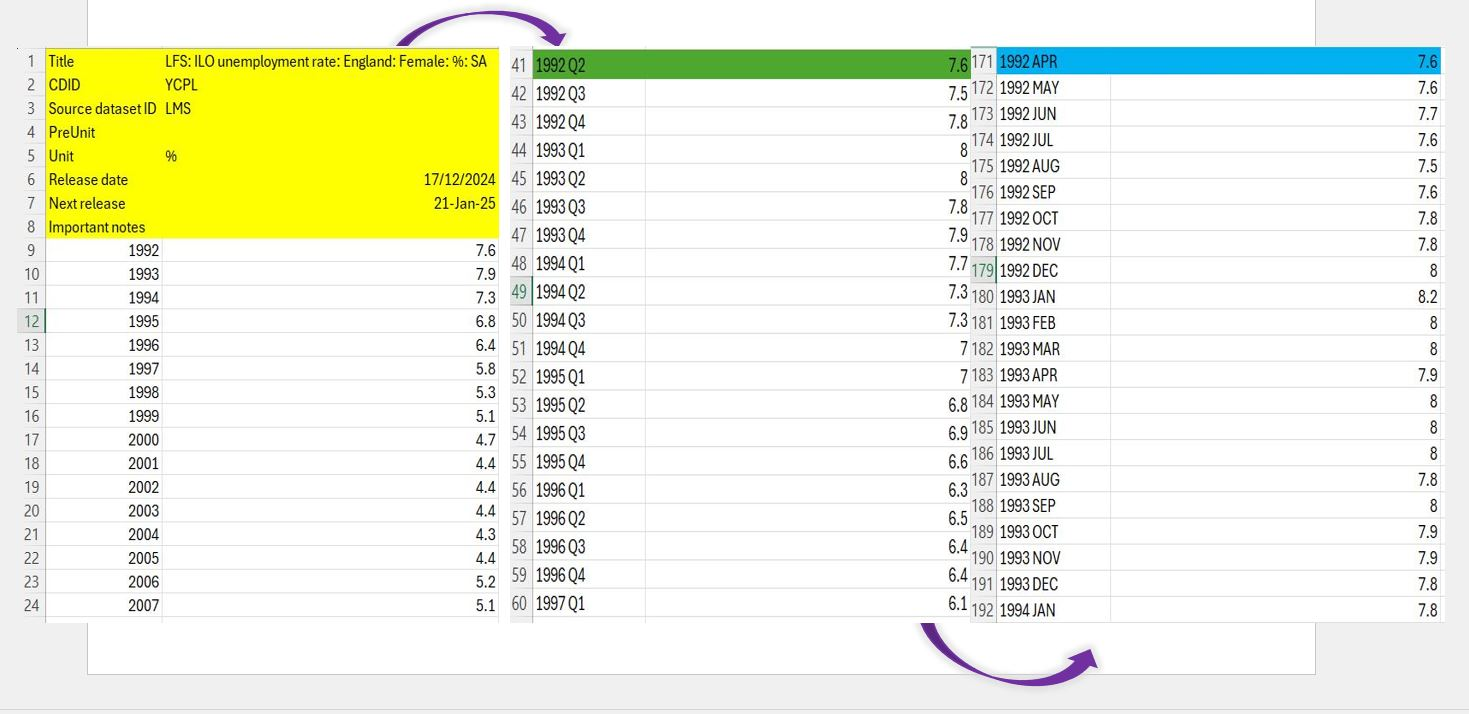

Here we assume that the focus is on the monthly "part" of the dataset ( i.e., "1992 APR"). Running the Python code below, helps us to skip any metadata rows to focus only on the  monthly data.

In [228]:
import pandas as pd
import requests
from io import StringIO

# URL for the dataset
url = "https://www.ons.gov.uk/generator?format=csv&uri=/employmentandlabourmarket/peoplenotinwork/unemployment/timeseries/ycpl/lms"

# Fetch the dataset using requests
response = requests.get(url)

if response.status_code == 200:
    print("Dataset fetched successfully.")
    
    # Load the CSV data while skipping metadata rows and focusing on monthly data
    data = StringIO(response.text)
    monthly_data = pd.read_csv(data, skiprows=170, names=['Date', 'Unemployment Rate (%)'])
    
    # Convert 'Date' to datetime format (e.g., "1992 APR" -> datetime)
    monthly_data['Date'] = pd.to_datetime(monthly_data['Date'], format='%Y %b', errors='coerce')
    
    # Drop rows with invalid dates (NaT values)
    monthly_data = monthly_data.dropna(subset=['Date'])

    # Restrict data to end at December 2022
    monthly_data = monthly_data[monthly_data['Date'] <= '2022-12-31']

    # Transform into "long format"
    monthly_data_long = monthly_data.rename(columns={
        'Date': 'Date',
        'Unemployment Rate (%)': 'Value'
    })
    monthly_data_long['id'] = 'Unemp Rate (female)'

    # Display transformed dataset
    print("\nTransformed Monthly Dataset (Long Format):")
    print(monthly_data_long.head())
else:
    print(f"Failed to fetch dataset. HTTP Status Code: {response.status_code}")


Dataset fetched successfully.

Transformed Monthly Dataset (Long Format):
        Date  Value                   id
0 1992-04-01    7.6  Unemp Rate (female)
1 1992-05-01    7.6  Unemp Rate (female)
2 1992-06-01    7.7  Unemp Rate (female)
3 1992-07-01    7.6  Unemp Rate (female)
4 1992-08-01    7.5  Unemp Rate (female)


The `PD.to_datetime(monthly_data['Date'],` function converts the "Date" column (e.g., "1992 APR") into a proper datetime format and filters the dataset to include records up to December 2022. By using the `monthly_data.rename()` function, the data is then transformed into a "long format" by renaming columns to Date, Value and adding an id column ("Unemp Rate (female)"), making it suitable for time series analysis and plotting. This ensures the dataset is clean, structured, and ready for further analysis or visualization.

##### Inflation rate (D7OE in database MM23)

By downloading the Inflation rate .csv datafile, we can see that the dataset includes monthly data. At this point, we would just need to skip any metadata rows to focus only on the monthly data.

In [244]:
import pandas as pd
import requests
from io import StringIO

# URL for the inflation dataset
url = "https://www.ons.gov.uk/generator?format=csv&uri=/economy/inflationandpriceindices/timeseries/d7oe/mm23"

# Fetch the dataset using requests
response = requests.get(url)

if response.status_code == 200:
    print("Dataset fetched successfully.")
    
    # Load the CSV data while skipping metadata rows
    data = StringIO(response.text)
    inflation_data = pd.read_csv(data, skiprows=8, names=['Date', 'CPI Inflation (%)'])
    
    # Convert 'Date' to datetime format (e.g., "1988 FEB" -> datetime)
    inflation_data['Date'] = pd.to_datetime(inflation_data['Date'], format='%Y %b', errors='coerce')
    
    # Drop rows with invalid dates (NaT values)
    inflation_data = inflation_data.dropna(subset=['Date'])

    # Restrict data to end at December 2022
    inflation_data = inflation_data[inflation_data['Date'] <= '2022-12-31']

    # Transform into "long format"
    inflation_data_long = inflation_data.rename(columns={
        'Date': 'Date',
        'CPI Inflation (%)': 'Value'
    })
    inflation_data_long['id'] = 'CPI Inflation'

    # Display transformed dataset
    print("\nTransformed Monthly Dataset (Long Format):")
    print(inflation_data_long.head())
else:
    print(f"Failed to fetch dataset. HTTP Status Code: {response.status_code}")


Dataset fetched successfully.

Transformed Monthly Dataset (Long Format):
        Date  Value             id
0 1988-02-01    0.3  CPI Inflation
1 1988-03-01    0.3  CPI Inflation
2 1988-04-01    1.2  CPI Inflation
3 1988-05-01    0.5  CPI Inflation
4 1988-06-01    0.4  CPI Inflation


The` pd.to_datetime(monthly_data['Date'], ...)` function converts the "Date" column (e.g., "1988 FEB") into a proper datetime format, ensuring consistency in date representation. The dataset is then filtered to include records only up to December 2022, ensuring it focuses on the most relevant period. By using the `monthly_data.rename()` function, the data is transformed into a "long format" by renaming columns to `Date` and `Value` and adding an `id` column ("CPI Inflation").

##### Combine the dataframes

Now we put both series into one dataframe by attaching the individual dataframes. To combine the `unemployment rate` and `inflation rate` datasets into one DataFrame in Python, we can use the `pd.concat()` function, as shown below:

In [253]:
import pandas as pd

# Display the unemployment dataset
print("\nUnemployment Rate Dataset:")
print(monthly_data_long.head())

# Display the inflation dataset
print("\nInflation Rate Dataset:")
print(inflation_data_long.head())

# Combine both datasets
combined_data = pd.concat([monthly_data_long, inflation_data_long], ignore_index=True)

# Display the combined dataset
print("\nFull Combined Dataset:")
print(combined_data)



Unemployment Rate Dataset:
        Date  Value                   id
0 1992-04-01    7.6  Unemp Rate (female)
1 1992-05-01    7.6  Unemp Rate (female)
2 1992-06-01    7.7  Unemp Rate (female)
3 1992-07-01    7.6  Unemp Rate (female)
4 1992-08-01    7.5  Unemp Rate (female)

Inflation Rate Dataset:
        Date  Value             id
0 1988-02-01    0.3  CPI Inflation
1 1988-03-01    0.3  CPI Inflation
2 1988-04-01    1.2  CPI Inflation
3 1988-05-01    0.5  CPI Inflation
4 1988-06-01    0.4  CPI Inflation

Full Combined Dataset:
          Date  Value                   id
0   1992-04-01    7.6  Unemp Rate (female)
1   1992-05-01    7.6  Unemp Rate (female)
2   1992-06-01    7.7  Unemp Rate (female)
3   1992-07-01    7.6  Unemp Rate (female)
4   1992-08-01    7.5  Unemp Rate (female)
..         ...    ...                  ...
783 2022-08-01    0.5        CPI Inflation
784 2022-09-01    0.5        CPI Inflation
785 2022-10-01    2.0        CPI Inflation
786 2022-11-01    0.4        CPI Infl

[//]: # (-.- .unlisted .unnumbered)

Now, it may be more obvious why we called this the “long” format, as the data all appear in the same column. The `id` variable differentiates different variables. Let’s produce some time series plots and ACF functions. 

In [261]:
from lets_plot import *
LetsPlot.setup_html()

# Filter data for each time series
unemp_data = combined_data[combined_data['id'] == "Unemp Rate (female)"]
inflation_data = combined_data[combined_data['id'] == "CPI Inflation"]

# Create plot for Female Unemployment Rate
plot_unemp = ggplot(unemp_data, aes(x='Date', y='Value')) + \
    geom_line(color='blue', size=1.0) + \
    ggtitle("Female Unemployment Rate") + \
    xlab("Date") + \
    ylab("Rate (%)") + \
    theme_minimal()

# Create plot for Inflation Rate
plot_inflation = ggplot(inflation_data, aes(x='Date', y='Value')) + \
    geom_line(color='blue', size=1.0) + \
    ggtitle("Inflation Rate") + \
    xlab("Date") + \
    ylab("Rate (%)") + \
    theme_minimal()

# Combine the two plots side-by-side
combined_plots = gggrid([plot_unemp, plot_inflation], ncol=2)

# Show the combined plot
combined_plots.show()


In Python, we utilized the `Lets-Plot` library and its `gggrid` function to create a layout similar to `grid.arrange(p1, p2, nrow=1, ncol=2)` in R. This method allowed us to arrange two plots side by side in a single row, making it visually effective for comparing related datasets, such as the female unemployment rate and the inflation rate.

The `gggrid` function simplifies combining multiple plots by specifying the number of columns (`ncol=2`) to arrange the plots horizontally. Each subplot is separately created using `ggplot` and populated with aesthetics, titles, and labels that suit its respective dataset. For instance:

The first plot visualizes the female unemployment rate with clear axes, a blue line, and a descriptive title.
The second plot displays the inflation rate with similar styling for consistency.

What if we want to combine the two time-series into one graph (this makes sense if they exist on a similar scale)? In this case, we can use the `Lets-Plot `library. The code filters the combined dataset to include only the selected series and uses `ggplot` to plot them with different colours based on the `id` variable:

In [264]:
from lets_plot import *

# Setup Lets-Plot
LetsPlot.setup_html()

# Filter the data for the two series we want to display
filtered_data = combined_data[combined_data['id'].isin(["CPI Inflation", "Unemp Rate (female)"])]

# Create the plot
plot_combined = ggplot(filtered_data, aes(x='Date', y='Value', color='id')) + \
    geom_line(size=1.0) + \
    ggtitle("Various Time-Series") + \
    xlab("Date") + \
    ylab("Value") + \
    theme_minimal() + \
    scale_color_manual(values=['red', 'cyan'])  # Custom colors for the two series

# Display the plot
plot_combined.show()


Now we return to the ACFs. We now use the `gggrid()` function which tells Python to arrange multiple plots in a grid layout, specifying the number of rows and columns.

The dataset is filtered to separate `Unemp Rate (female)` and `CPI Inflation` using the `id` column. Then the `acf()` function computes autocorrelation values for both series up to 25 lags. The ACF values are stored in` unemp_acf_df` and `inflation_acf_df` DataFrames, with `Lag` and `ACF` columns.

It will be interesting to see what happens when we difference data series (or often their logs as this approximates growth rates). Here we can use `numpy` for log differencing, `statsmodels` for the ACF calculation, and `Lets-Plot` for visualization. 

In [297]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import acf
from lets_plot import *

# Setup Lets-Plot
LetsPlot.setup_html()

# Combined Dataset (ensure this contains "CPI Inflation" and "Unemp Rate (female)")
# Assuming `combined_data` is already loaded

# Create log-differenced series (growth rates)
combined_data['Log Value'] = np.log(combined_data['Value'])
combined_data['Log Diff'] = combined_data.groupby('id')['Log Value'].diff()

# Filter for CPI Inflation and Unemp Rate (female) datasets
inflation_data = combined_data[combined_data['id'] == "CPI Inflation"]
unemp_data = combined_data[combined_data['id'] == "Unemp Rate (female)"]

# Define a function to compute ACF and prepare for plotting
def compute_acf(data, series_name):
    acf_values = acf(data['Log Diff'].dropna(), nlags=25, fft=True, missing='drop')
    return (
        pd.DataFrame({'Lag': range(len(acf_values)), 'ACF': acf_values}),
        ggplot(data, aes(x='Date', y='Log Diff')) +
        geom_line(color='blue' if series_name == "CPI Inflation" else 'red') +
        ggtitle(f"{series_name} Growth Rate") +
        xlab("Date") + ylab("Log Diff") + theme_minimal()
    )

# Compute ACF for each dataset
inflation_acf_df, inflation_plot = compute_acf(inflation_data, "CPI Inflation")
unemp_acf_df, unemp_plot = compute_acf(unemp_data, "Unemp Rate (female)")

# Create ACF plots
inflation_acf_plot = ggplot(inflation_acf_df, aes(x='Lag', y='ACF')) + \
    geom_bar(stat='identity', color='blue', fill='blue') + \
    ggtitle("CPI Inflation ACF") + \
    xlab("Lag") + \
    ylab("ACF") + \
    theme_minimal()

unemp_acf_plot = ggplot(unemp_acf_df, aes(x='Lag', y='ACF')) + \
    geom_bar(stat='identity', color='red', fill='red') + \
    ggtitle("Unemp Rate (female) ACF") + \
    xlab("Lag") + \
    ylab("ACF") + \
    theme_minimal()

# Combine plots in a 2x2 grid
gggrid(
    [inflation_plot, unemp_plot, inflation_acf_plot, unemp_acf_plot],
    ncol=2
).show()


The Python code here analyses "CPI Inflation" and "Unemp Rate (female)" datasets by first transforming them into log-differenced series to approximate growth rates. The `Log Value` column calculates the natural logarithm of the original values, and `Log Diff` computes the first difference to capture changes over time. The datasets are then filtered separately for the two variables. The `compute_acf` function calculates the autocorrelation function (ACF) for these log-differenced series using 25 lags and creates growth rate plots. Additionally, bar plots visualize the ACF values for each dataset. Finally, all plots—growth rates and ACFs—are arranged in a 2x2 grid layout using `gggrid` from Lets-Plot, enabling clear side-by-side comparisons of the growth rates and their temporal dependencies.

As you can see, the original series often shows a slowly decaying autocorrelation function (ACF), a hallmark of non-stationary data. However, the ACF decays much more rapidly after applying differencing (using log differences to approximate growth rates). This indicates that differencing effectively transforms a non-stationary series into a stationary one by eliminating trends and seasonality. While formal tests like the Augmented Dickey-Fuller (ADF) test provide a rigorous way to assess stationarity, visually analyzing ACF plots offers a straightforward and insightful method to identify non-stationarity and evaluate the impact of such transformations.

# Simple Time Series Regression Analysis

Using time series regression, let's run a simple regression model to explore the relationship between economic growth and unemployment. The objective is to understand how changes in Real GDP influence the unemployment rate over time. 

### The Regression Model

We use a simple linear regression model where the dependent variable is the unemployment rate transformed from monthly to quarterly frequency, and the independent variable is the quarterly Real GDP data. 

The regression equation is mathematically represented as follows:

$$ U_t = \beta_0 + \beta_1 \cdot GDP_t + \epsilon_t $$

**Where:**

- $U_t$: Unemployment rate at time $t$
- $GDP_t$: Real Gross Domestic Product at time $t$
- $\beta_0$: Intercept of the regression line
- $\beta_1$: Slope of the regression line, indicating the change in unemployment rate for a one unit change in Real GDP
- $\epsilon_t$: Error term at time $t$, representing the discrepancy between observed values and those predicted by the model

### Objective

The analysis will provide insights into how economic growth, as indicated by changes in Real GDP, affects labour market conditions, precisely the unemployment rate. This could be crucial for policymakers and economic analysts focusing on employment strategies and economic planning.

To prepare the data for this analysis in Python, we resample the monthly unemployment data to quarterly data, ensuring that both time series are aligned on the same quarterly scale. This synchronization is crucial for the validity of our regression analysis. In Python, while we don't have an exact equivalent to R's `to.period()` function, we can achieve similar results by resampling the data using pandas functionalities, which are well-suited for handling date and time series data.


In [503]:
import pandas as pd
import requests
from io import StringIO

# Define the URL
url = "https://www.ons.gov.uk/generator?format=csv&uri=/employmentandlabourmarket/peoplenotinwork/unemployment/timeseries/ycpl/lms"

# Use requests to get the content
response = requests.get(url)

# Check if the request was successful
if response.status_code == 200:
    data = StringIO(response.text)

    # Read the data into a pandas DataFrame, skipping the first 40 rows and taking the next 130 rows
    unemp_data = pd.read_csv(data, skiprows=40, nrows=130, header=None)

    # Rename the columns
    unemp_data.columns = ['Quarter', 'Unemp Rate (female)']

    # Optional: Reset index if you want the index to start from 0 without the original row numbers
    unemp_data.reset_index(drop=True, inplace=True)

    # Display the DataFrame to verify the column names and data
    print(unemp_data.head())
else:
    print(f"Failed to retrieve data: {response.status_code}")


   Quarter  Unemp Rate (female)
0  1992 Q2                  7.6
1  1992 Q3                  7.5
2  1992 Q4                  7.8
3  1993 Q1                  8.0
4  1993 Q2                  8.0


It is important to note that in order to resample the monthly 'Unemployment dataset' to quarterly data, you will need to  skip the appropriate number of rows to ignore irrelevant data and only load the rows relevant to quarterly data. In this case, we **skip the first 40 rows** and take the next 130 rows which represent the quarterly "part" of the 'Unemployment dataset'. Let's no have a look at the GDP dataset which is represented by the 'quarterly_data'. 

In [529]:
print(quarterly_data.head())

     Quarter  Real GDP
0 1955-03-31    134886
1 1955-06-30    134924
2 1955-09-30    137592
3 1955-12-31    136813
4 1956-03-31    138343


**What do you notice here?** We are dealing with different date formats in each time series dataset's 'Quarter' column. Specifically, 'quarterly_data' uses specific date formats (e.g., 1955-03-31), while 'unemp_data' uses a more general quarter representation (e.g., 1992 Q2).To merge the two datasets ('quarterly_data' and 'unemp_data'), you need to **standardize** the date formats so they match. 

In [531]:
import pandas as pd

# Convert 'Quarter' from '1955-03-31' format to '1955 Q1'
quarterly_data['Quarter'] = pd.to_datetime(quarterly_data['Quarter'])

# Convert to 'Year QQuarter' format
quarterly_data['Quarter'] = quarterly_data['Quarter'].dt.to_period('Q').dt.strftime('%Y Q%q')

# Check the transformation
print("Transformed quarterly_data:")
print(quarterly_data.head())

# Assuming 'unemp_data' is also loaded and formatted correctly
# If needed to merge, now both should have the same format
# merged_data = pd.merge(quarterly_data, unemp_data, on='Quarter', how='inner')

# Print the merged DataFrame
# print("Merged Data:")
# print(merged_data.head())


Transformed quarterly_data:
   Quarter  Real GDP
0  1955 Q1    134886
1  1955 Q2    134924
2  1955 Q3    137592
3  1955 Q4    136813
4  1956 Q1    138343


We now have two quarterly series `Unemp Rate (female)` and `quarterly_data` which represents here the **Real GDP**. We shall merge them into the same dataframe.

In [541]:
# Now merge the quarterly datasets
reg_data = pd.merge(
    unemp_data,
    quarterly_data,
    on='Quarter',
    how='inner'
)

# Display the merged dataset
print("\nRegression Dataset (Last 10 Observations):")
print(reg_data.tail(10))


Regression Dataset (Last 10 Observations):
     Quarter  Unemp Rate (female)  Real GDP
120  2022 Q2                  3.8    631258
121  2022 Q3                  3.8    631977
122  2022 Q4                  4.0    634044
123  2023 Q1                  3.9    634807
124  2023 Q2                  4.0    634866
125  2023 Q3                  3.8    634052
126  2023 Q4                  3.6    632365
127  2024 Q1                  4.4    637023
128  2024 Q2                  4.1    639269
129  2024 Q3                  4.3    639452


The last 10 observations in your dataset show that the dates for the quarterly unemployment rate and CPI inflation have been successfully aligned and matched. This alignment is crucial for conducting accurate time series analyses, such as regression modelling, where the synchronization of data points over the same intervals ensures the validity of the results. The data is in a wide format, which is ideal for regression analysis, where each variable (CPI Inflation and Unemployment Rate) occupies its own column. 

We can now feed the data into the `statsmodels.api.OLS` function for fitting the ordinary least squares regression, and then display the results using  the [stargazer_HAC.py](https://github.com/SimoKF/Drafting-Python-resources-for-ECLR/blob/main/stargazer_hac.ipynb) package. Before actually running the model, it is important to ensure that the "Quarter" column exists in both datasets. We can do this by running the following code:

In [627]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.sandwich_covariance import cov_hac
from stargazer.stargazer import Stargazer
from pandas.tseries.offsets import QuarterEnd


# Step 1: Prepare the regression model
# 'Real GDP - Quarterly' is the independent variable from 'quarterly_data'
# 'Unemp Rate (female) - Quarterly' is the dependent variable from 'unemp_data'
X = sm.add_constant(reg_data['Real GDP'])  # Add constant for intercept
y = reg_data['Unemp Rate (female)']

# Step 2: Fit the regression model
model = sm.OLS(y, X).fit()

# Step 3: Define custom Stargazer function with Newey-West standard errors
def stargazer_hac(models, type_out="html", omit_stats=None, out=None):
    if not isinstance(models, list):
        models = [models]
    
    # Apply Newey-West standard errors
    for model in models:
        nw_cov = cov_hac(model)
        model.cov_params_default = nw_cov # Format output using Stargazer
    stargazer = Stargazer(models)
    if omit_stats:
        stargazer.omit_statistics(omit_stats)
    stargazer.add_custom_notes(["Newey-West standard errors in parentheses"])

    # Generate output
    if type_out == "html":
        output = stargazer.render_html()
    elif type_out == "latex":
        output = stargazer.render_latex()
    else:
        raise ValueError("Unsupported output format. Use 'html' or 'latex'.")
    
    # Display or save the output
    if out:
        with open(out, 'w') as file:
            file.write(output)
    else:
        from IPython.display import display, HTML
        display(HTML(output))

# Step 4: Display the regression results
stargazer_hac([model], type_out="html")


The coefficient for Real GDP is -0.000 with a significance level marked by three asterisks (***), indicating statistical significance at a p-value less than 0.01. This means that the negative relationship between Real GDP and the unemployment rate is statistically significant. This seems to suggest that higher GDP significantly reduces the unemployment rate.

> At this point, it is important to note that the relationship is statistically significant, but the actual size of the effect (economic significance) is very small. This aspect suggests that the impact of Real GDP on the unemployment rate, while statistically significant, may be economically small.

Let’s have a look at the residuals.

In [629]:
from lets_plot import *
LetsPlot.setup_html()
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import acf

# Assuming 'model' is your fitted regression model from statsmodels
residuals = model.resid

# Create a DataFrame for plotting
data = pd.DataFrame({
    'Residuals': residuals,
    'Index': np.arange(len(residuals))
})

# Plot residuals
p1 = ggplot(data, aes('Index', 'Residuals')) + \
    geom_line() + \
    ggtitle('Model 1 - Residuals') + \
    theme(axis_title_x='blank', axis_title_y='blank')

# Calculate ACF for residuals
acf_res = acf(residuals, nlags=20, fft=False)

# Create a DataFrame for the ACF
acf_data = pd.DataFrame({
    'ACF': acf_res,
    'Lag': range(len(acf_res))
})

# Plot ACF
p2 = ggplot(acf_data, aes('Lag', 'ACF')) + \
    geom_bar(stat='identity', fill='#4682B4', alpha=0.7) + \
    geom_hline(yintercept=0, color="red", linetype="dashed", size=0.5) + \
    ggtitle('Series model1 Residuals') + \
    theme(axis_title_x='blank', axis_title_y='blank')

# Combine the two plots side-by-side
combined_plots = gggrid([p1, p2], ncol=2)

# Show the combined plot
combined_plots.show()


Important observations:

1. **Residuals Plot**: The line graph showing the residuals over time reveals fluctuations that might indicate patterns or cycles. However, a deeper time-series analysis or diagnostic tests would be necessary to confirm any specific type of autocorrelation or other statistical properties.
2. **ACF Plot**: The bar chart showing the ACF of the residuals provides more direct evidence regarding **autocorrelation**. The plot shows that several lags are significantly different from zero (not crossing the blue dashed lines, which typically represent confidence intervals), suggesting that the residuals are not white noise.

We could now apply the Breusch-Godfrey hypothesis test using the statsmodels library, which includes a function specifically for this test (`sm.stats.acorr_breusch_godfrey`). The Breusch-Godfrey test is used to check for autocorrelation in the residuals of a regression model, and it is beneficial in the context of time series analysis. The null hypothesis ($H_0$) for the Breusch-Godfrey test is that there is no autocorrelation up to the specified lag order.

In [631]:
import statsmodels.api as sm

# Assuming 'model' is your fitted OLS model from statsmodels
# Specify the number of lags you are testing for
nlags = 4  # This is equivalent to 'order=4' in R's bgtest

# Perform the Breusch-Godfrey test
test_result = sm.stats.acorr_breusch_godfrey(model, nlags=nlags)

# Print the results
print("Breusch-Godfrey test results:")
print("LM test statistic:", test_result[0])
print("LM test p-value:", test_result[1])
print("F-statistic:", test_result[2])
print("F-test p-value:", test_result[3])


Breusch-Godfrey test results:
LM test statistic: 123.32845990173898
LM test p-value: 1.0389267027020207e-25
F-statistic: 573.0584243884836
F-test p-value: 6.521742589897091e-79


The p-value is effectively 0, suggesting strong evidence to reject the null hypothesis of no autocorrelation. This means that the residuals exhibit significant autocorrelation, violating the assumptions of OLS regression. Furthermore, as observed earlier, GDP and the female unemployment rate are nonstationary time-series. Regressions involving nonstationary series, especially when the residuals are also nonstationary (as in this case), can lead to spurious results. Therefore, we cannot take these regression results seriously without addressing the issue of nonstationarity. Further analysis will involve appropriate transformations (e.g., differencing) or cointegration tests to address these issues.

# Simple Regression Model with Differenced Time Series Data

In this section, we will re-run the simple regression model using **stationary time series data**. To address the issue of nonstationarity, we will model the **differenced logs** of GDP and the unemployment rate, as differencing transforms nonstationary data into stationary data (assuming they are integrated of the same order).

The model we will estimate is:

$$
\Delta ur_t = \alpha + \beta \Delta rGDP_t + u_t
$$

Where:
- $\Delta ur_t$: The change (first difference) in the log of the unemployment rate at time $t$,
- $\Delta rGDP_t$: The change (first difference) in the log of Real GDP at time $t$,
- $\alpha$: The intercept,
- $\beta$: The slope coefficient, representing the effect of changes in GDP on changes in the unemployment rate,
- $u_t$: The error term at time $t$.

#### Why Use Differenced Logs?
1. **Nonstationary Time Series**: The original GDP and unemployment rate series are nonstationary, which makes regression results unreliable.
2. **Log Transformation**: Log transformation linearizes exponential growth patterns, making the relationships between variables easier to interpret.
3. **First Differences**: Differencing removes trends, ensuring stationarity.

#### Implementation Steps
1. Create new variables in the DataFrame for the differenced logs of the unemployment rate ($\Delta ur_t$) and GDP ($\Delta rGDP_t$).
2. Run a simple regression model using these differenced log variables.
3. Analyze the results to determine the relationship between changes in GDP and changes in the unemployment rate.

##### Step 1: Create new variables.

As we will be modelling the differenced logs of the GDP and unemployment rate it is most convenient to create these variables explicitly in the data frame, otherwise we will have to deal with very long variable names.

In [633]:
import numpy as np
import pandas as pd

# Assuming `reg_data` is your DataFrame and columns are named 'real.GDP' and 'ur_female.Close'

# Create differenced logs and multiply by 100 to express in percentage points
reg_data['d_lgdp'] = 100 * np.log(reg_data['Real GDP']).diff()
reg_data['d_lur'] = 100 * np.log(reg_data['Unemp Rate (female)']).diff()

# Display the first few rows to verify
print(reg_data[['d_lgdp', 'd_lur']].head())

     d_lgdp     d_lur
0       NaN       NaN
1  0.474542 -1.324523
2  0.767613  3.922071
3  0.498898  2.531781
4  0.445103  0.000000


We can now feed the data into the `statsmodels.api.OLS` function.


In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.sandwich_covariance import cov_hac
from stargazer.stargazer import Stargazer

# Step 1: Define the dependent and independent variables
# 'd_lgdp' is the independent variable (Δlog(GDP))
# 'd_lur' is the dependent variable (Δlog(Unemployment Rate))
X = sm.add_constant(reg_data['d_lgdp'])  # Add constant for the intercept
y = reg_data['d_lur']

# Step 2: Fit the regression model
model = sm.OLS(y, X).fit()

# Step 3: Define a custom Stargazer function with Newey-West standard errors
def stargazer_hac(models, type_out="html", omit_stats=None, out=None):
    if not isinstance(models, list):
        models = [models]
    
    # Apply Newey-West standard errors
    for model in models:
        nw_cov = cov_hac(model)
        model.cov_params_default = nw_cov
    
    # Format output using Stargazer
    stargazer = Stargazer(models)
    if omit_stats:
        stargazer.omit_statistics(omit_stats)
    stargazer.add_custom_notes(["Newey-West standard errors in parentheses"])
    
    # Generate output
    if type_out == "html":
        output = stargazer.render_html()
    elif type_out == "latex":
        output = stargazer.render_latex()
    else:
        raise ValueError("Unsupported output format. Use 'html' or 'latex'.")
    
    # Display or save the output
    if out:
        with open(out, 'w') as file:
            file.write(output)
    else:
        from IPython.display import display, HTML
        display(HTML(output))

# Step 4: Display the regression results
stargazer_hac([model], type_out="html")


When running this code you will most likely come across an error. Thsi error indicates that your independent variable (`d_lgdp`) contains missing (`NaN`) or infinite (`inf`) values, which the `statsmodels` library cannot handle. This issue is likely caused by the `.diff()` operation used to create the differenced log variables (`d_lgdp` and `d_lur`), which introduces `NaN` values for the first observation in the dataset.

> It is important to note here that R **automatically** drops rows with missing values (`NA`) when fitting the `lm` function. However, Python requires explicit handling of missing values.

What we need to do is to **drop rows** with **missing** or **infinite values** from the dataset before fitting the model.

In [657]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.sandwich_covariance import cov_hac
from stargazer.stargazer import Stargazer
from IPython.display import display, HTML

# Step 1: Drop missing values 
# This will ensure that rows with NaN in either d_lgdp or d_lur are removed
data_clean = reg_data[[ 'd_lgdp', 'd_lur']].dropna()

# Step 2: Define independent (X) and dependent (y) variables
X = sm.add_constant(data_clean['d_lgdp'])  # Add constant for intercept
y = data_clean['d_lur']

# Step 3: Fit the regression model (using a unique name)
model_differenced = sm.OLS(y, X).fit()

# Step 4: Define a function for displaying regression results with Newey-West standard errors
def stargazer_hac(models, type_out="html", omit_stats=None, out=None):
    if not isinstance(models, list):
        models = [models]
    
    # Apply Newey-West standard errors
    for model in models:
        nw_cov = cov_hac(model)
        model.cov_params_default = nw_cov
    
    # Format output using Stargazer
    stargazer = Stargazer(models)
    if omit_stats:
        stargazer.omit_statistics(omit_stats)
    stargazer.add_custom_notes(["Newey-West standard errors in parentheses"])
    
    # Generate output
    if type_out == "html":
        output = stargazer.render_html()
    elif type_out == "latex":
        output = stargazer.render_latex()
    else:
        raise ValueError("Unsupported output format. Use 'html' or 'latex'.")
    
    # Display or save the output
    if out:
        with open(out, 'w') as file:
            file.write(output)
    else:
        display(HTML(output))

# Step 5: Display the regression results
stargazer_hac([model_differenced], type_out="html")

We can indicate that the initial significant relationship between GDP and unemployment rate in the non-stationary data appears to be spurious, driven by shared trends rather than a true economic relationship. After differencing to ensure stationarity, the relationship disappears, indicating **no statistically significant relationship between GDP growth and the growth in the unemployment rate.**

This reinforces a key lesson in econometrics: **regressions with non-stationary data can yield misleading results**. Always check for stationarity and use appropriate transformations (e.g., differencing) to ensure valid inferences.

Let’s have a look at the residuals.

In [663]:
from lets_plot import *
LetsPlot.setup_html()
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import acf

# Step 1: Extract residuals from the fitted model
residuals = model_differenced.resid  # Use the residuals from your differenced model

# Step 2: Create a DataFrame for plotting residuals
residuals_data = pd.DataFrame({
    'Residuals': residuals,
    'Index': np.arange(len(residuals))
})

# Step 3: Plot residuals as a line plot
p1 = ggplot(residuals_data, aes('Index', 'Residuals')) + \
    geom_line() + \
    ggtitle('Model - Residuals') + \
    theme(axis_title_x='blank', axis_title_y='blank')

# Step 4: Calculate ACF for residuals
acf_res = acf(residuals, nlags=20, fft=False)  # Autocorrelation function

# Step 5: Create a DataFrame for the ACF values
acf_data = pd.DataFrame({
    'ACF': acf_res,
    'Lag': range(len(acf_res))
})

# Step 6: Plot ACF
p2 = ggplot(acf_data, aes('Lag', 'ACF')) + \
    geom_bar(stat='identity', fill='#4682B4', alpha=0.7) + \
    geom_hline(yintercept=0, color="red", linetype="dashed", size=0.5) + \
    ggtitle('Series Residuals - ACF') + \
    theme(axis_title_x='blank', axis_title_y='blank')

# Step 7: Combine the two plots side-by-side using gggrid
combined_plots = gggrid([p1, p2], ncol=2)

# Step 8: Show the combined plot
combined_plots.show()


Interpretation of the Results

1. **Residuals Plot**:

- The left plot shows the residuals over time.
- The residuals appear to fluctuate randomly around zero, but there are some larger deviations (spikes) towards the end.
- This suggests that while there is no obvious trend or cycle in the residuals, the variance may not be constant throughout the series.
  
2. **ACF Plot**:

- The right plot shows the autocorrelation function (ACF) of the residuals.
- Most of the autocorrelation values are within the confidence bands (indicating no significant autocorrelation at those lags).
- However, there is a small positive autocorrelation at **lag 2**, which might warrant further investigation.

We can again apply the hypothesis test the Breusch-Godfrey test (`sm.stats.acorr_breusch_godfrey`). The null hypothesis is that there is no autocorrelation.

In [669]:
import statsmodels.api as sm

# Perform the Breusch-Godfrey test for autocorrelation
bg_test = sm.stats.acorr_breusch_godfrey(model_differenced, nlags=4)  # Specify lag order (e.g., 4)

# Display the results
print("Breusch-Godfrey test results:")
print(f"LM test statistic: {bg_test[0]}")
print(f"LM test p-value: {bg_test[1]}")
print(f"F-statistic: {bg_test[2]}")
print(f"F-test p-value: {bg_test[3]}")


Breusch-Godfrey test results:
LM test statistic: 15.115507347857937
LM test p-value: 0.004467546334679332
F-statistic: 4.081344528322748
F-test p-value: 0.003849894997821302


The test results indicate that **there is evidence of autocorrelation in the residuals**, even after differencing the time series data. Fortunately, the **Heteroskedasticity and Autocorrelation Consistent (HAC)** standard errors used in the regression output already account for autocorrelation in the residuals. This means the reported standard errors and statistical tests are robust to the detected autocorrelation!

# ADL Models

When estimating regression models with time-series data, we often consider the inclusion of lagged variables. Lagged variables allow us to account for dynamic relationships over time.

The model can be expressed as:

$$
\Delta ur_t = \alpha + \beta_0 \Delta rGDP_t + \beta_1 \Delta rGDP_{t-1} + \beta_2 \Delta rGDP_{t-2} + \gamma_1 \Delta ur_{t-1} + \gamma_2 \Delta ur_{t-2} + u_t
$$

- $ \Delta ur_t $: Change in the unemployment rate at time $ t $.
- $ \Delta rGDP_t $: Change in real GDP at time $ t $.
- $ \beta_0, \beta_1, \beta_2 $: Coefficients for contemporaneous and lagged changes in real GDP.
- $ \gamma_1, \gamma_2 $: Coefficients for lagged changes in the unemployment rate.
- $ u_t $: Error term capturing unexplained variations.

Including these lagged variables allows us to better capture the dynamic effects of GDP changes on unemployment rates over time.   

To estimate an Autoregressive Distributed Lag (ADL) model in Python with lagged variables, you can follow this process:

- **Add Lagged Variables**: Use `pandas.DataFrame.shift()` to create lagged variables for the dependent (d_lur) and independent (d_lgdp) variables.
- **Fit the Model**: Use `statsmodels.OLS` to estimate the regression.
- **Apply HAC Standard Errors**: Use `statsmodels` to apply Newey-West standard errors for robustness.
- 
[//]: # (-.- .tabset)

##### Step 1: Add lagged variables for ADL model

In [676]:
# Create lags for dependent (d_lur) and independent (d_lgdp) variables
reg_data['lag_d_lur_1'] = reg_data['d_lur'].shift(1)  # Δurt−1
reg_data['lag_d_lur_2'] = reg_data['d_lur'].shift(2)  # Δurt−2
reg_data['lag_d_lgdp_1'] = reg_data['d_lgdp'].shift(1)  # ΔrGDPt−1
reg_data['lag_d_lgdp_2'] = reg_data['d_lgdp'].shift(2)  # ΔrGDPt−2

##### Step 2: Drop Missing Values

In [680]:
#  Drop rows with NaN values caused by lags
data_clean_adl = reg_data[['d_lur', 'd_lgdp', 'lag_d_lur_1', 'lag_d_lur_2', 'lag_d_lgdp_1', 'lag_d_lgdp_2']].dropna()

##### Step 3: Define X and Y

In [684]:
# Define independent (X) and dependent (y) variables
X_adl = sm.add_constant(data_clean_adl[['d_lgdp', 'lag_d_lgdp_1', 'lag_d_lgdp_2', 'lag_d_lur_1', 'lag_d_lur_2']])  # Independent variables
y_adl = data_clean_adl['d_lur']  # Dependent variable

##### Step 4: Fit ADL Model

In [688]:
# Fit the ADL regression model
model_adl = sm.OLS(y_adl, X_adl).fit()

##### Step 5: Newey-West standard errors

In [691]:
# Define a function for displaying regression results with Newey-West standard errors
def stargazer_hac(models, type_out="html", omit_stats=None, out=None):
    if not isinstance(models, list):
        models = [models]
    
    # Apply Newey-West standard errors
    for model in models:
        nw_cov = cov_hac(model)
        model.cov_params_default = nw_cov
    
    # Format output using Stargazer
    stargazer = Stargazer(models)
    if omit_stats:
        stargazer.omit_statistics(omit_stats)
    stargazer.add_custom_notes(["Newey-West standard errors in parentheses"])
    
    # Generate output
    if type_out == "html":
        output = stargazer.render_html()
    elif type_out == "latex":
        output = stargazer.render_latex()
    else:
        raise ValueError("Unsupported output format. Use 'html' or 'latex'.")
    
    # Display or save the output
    if out:
        with open(out, 'w') as file:
            file.write(output)
    else:
        display(HTML(output))

##### Step 6: Display ADL results

In [694]:
# Display the ADL regression results
stargazer_hac([model_adl], type_out="html")

[//]: # (-.- .unlisted .unnumbered)

Let's look at the residuals

In [697]:
from lets_plot import *
from statsmodels.tsa.stattools import acf
import pandas as pd
import numpy as np

# Set up LetsPlot for Jupyter
LetsPlot.setup_html()

# Extract residuals from the fitted ADL model
residuals_adl = model_adl.resid

# Step 1: Create a DataFrame for plotting residuals
residuals_data = pd.DataFrame({
    'Residuals': residuals_adl,
    'Index': np.arange(len(residuals_adl))
})

# Step 2: Plot residuals
p1 = ggplot(residuals_data, aes('Index', 'Residuals')) + \
    geom_line(color='black') + \
    ggtitle('ADL Model - Residuals') + \
    theme(axis_title_x='blank', axis_title_y='blank')

# Step 3: Calculate ACF for residuals
acf_residuals = acf(residuals_adl, nlags=20, fft=False)

# Step 4: Create a DataFrame for the ACF
acf_data = pd.DataFrame({
    'ACF': acf_residuals,
    'Lag': np.arange(len(acf_residuals))
})

# Step 5: Plot ACF
p2 = ggplot(acf_data, aes('Lag', 'ACF')) + \
    geom_bar(stat='identity', fill='#4682B4', alpha=0.7) + \
    geom_hline(yintercept=0, color='red', linetype='dashed', size=0.5) + \
    ggtitle('ACF of Residuals - ADL Model') + \
    theme(axis_title_x='blank', axis_title_y='blank')

# Step 6: Combine the two plots side-by-side
combined_plots_adl = gggrid([p1, p2], ncol=2)

# Step 7: Show the combined plots
combined_plots_adl.show()


Observations from the Residual Plot and ACF: 

1. **Residual Plot**:

- The residuals appear to fluctuate around zero, with no obvious trends or patterns.
- There is one notable spike towards the end, which could indicate a potential outlier or a specific event impacting the model.

2. **ACF Plot**:

- The autocorrelation of residuals decreases relatively quickly, which suggests some improvement in reducing autocorrelation compared to previous models.
- However, there are a few significant spikes at higher lags, indicating that some autocorrelation remains in the residuals, particularly at lag 2 and a few others.

In [705]:
from statsmodels.stats.diagnostic import acorr_breusch_godfrey

# Perform Breusch-Godfrey test for serial correlation of order up to 4
bg_test_results = acorr_breusch_godfrey(model_adl, nlags=4)

# Display the test results
print("Breusch-Godfrey Test Results:")
print(f"LM test statistic: {bg_test_results[0]}")
print(f"LM test p-value: {bg_test_results[1]}")
print(f"F-statistic: {bg_test_results[2]}")
print(f"F-test p-value: {bg_test_results[3]}")


Breusch-Godfrey Test Results:
LM test statistic: 8.476542708644143
LM test p-value: 0.07560145086615594
F-statistic: 2.0918970800721413
F-test p-value: 0.08622508402162118


At the **5% significance level**, we **fail to reject the null hypothesis** of no autocorrelation. This suggests there is **no significant evidence of serial correlation** in the residuals of the ADL model for lag order up to 4.

Now we remove the contemporaneous GDP growth rate ($ \Delta rGDP_t $) as this will be important if you wanted to produce forecasts from the unemployment rate from this model.

In [714]:
# Step 1: Prepare the data and drop missing values
data_clean_no_contemp = reg_data[['d_lur', 'lag_d_lgdp_1', 'lag_d_lgdp_2', 'lag_d_lur_1', 'lag_d_lur_2']].dropna()

# Step 2: Define independent (X) and dependent (y) variables without the contemporaneous GDP growth rate
X_no_contemp = data_clean_no_contemp[['lag_d_lgdp_1', 'lag_d_lgdp_2', 'lag_d_lur_1', 'lag_d_lur_2']]
X_no_contemp = sm.add_constant(X_no_contemp)  # Add constant for intercept
y = data_clean_no_contemp['d_lur']  # Dependent variable

# Step 3: Fit the regression model
model_adl_no_contemp = sm.OLS(y, X_no_contemp).fit()

# Step 4: Define a function for displaying regression results with Newey-West standard errors
def stargazer_hac(models, type_out="html", omit_stats=None, out=None):
    if not isinstance(models, list):
        models = [models]
    
    # Apply Newey-West standard errors
    for model in models:
        nw_cov = cov_hac(model)
        model.cov_params_default = nw_cov
    
    # Format output using Stargazer
    stargazer = Stargazer(models)
    if omit_stats:
        stargazer.omit_statistics(omit_stats)
    stargazer.add_custom_notes(["Newey-West standard errors in parentheses"])
    
    # Generate output
    if type_out == "html":
        output = stargazer.render_html()
    elif type_out == "latex":
        output = stargazer.render_latex()
    else:
        raise ValueError("Unsupported output format. Use 'html' or 'latex'.")
    
    # Display or save the output
    if out:
        with open(out, 'w') as file:
            file.write(output)
    else:
        display(HTML(output))

# Step 5: Display the regression results
stargazer_hac([model_adl_no_contemp], type_out="html")


Let's look at the residuals

In [717]:
from lets_plot import *
LetsPlot.setup_html()
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import acf

# Step 1: Extract residuals from the updated model
residuals_no_contemp = model_adl_no_contemp.resid

# Step 2: Create a DataFrame for residuals
data_residuals = pd.DataFrame({
    'Residuals': residuals_no_contemp,
    'Index': np.arange(len(residuals_no_contemp))
})

# Step 3: Plot residuals
p1 = ggplot(data_residuals, aes('Index', 'Residuals')) + \
    geom_line() + \
    ggtitle('ADL Model (No Contemporaneous GDP) - Residuals') + \
    theme(axis_title_x='blank', axis_title_y='blank')

# Step 4: Calculate ACF for residuals
acf_res_no_contemp = acf(residuals_no_contemp, nlags=20, fft=False)

# Step 5: Create a DataFrame for ACF
acf_data_no_contemp = pd.DataFrame({
    'ACF': acf_res_no_contemp,
    'Lag': range(len(acf_res_no_contemp))
})

# Step 6: Plot ACF
p2 = ggplot(acf_data_no_contemp, aes('Lag', 'ACF')) + \
    geom_bar(stat='identity', fill='#4682B4', alpha=0.7) + \
    geom_hline(yintercept=0, color="red", linetype="dashed", size=0.5) + \
    ggtitle('ACF of Residuals - ADL Model (No Contemporaneous GDP)') + \
    theme(axis_title_x='blank', axis_title_y='blank')

# Step 7: Combine the two plots side-by-side
combined_plots_no_contemp = gggrid([p1, p2], ncol=2)

# Step 8: Show the combined plot
combined_plots_no_contemp.show()


In [719]:
from statsmodels.stats.diagnostic import acorr_breusch_godfrey

# Perform Breusch-Godfrey test (order = 4)
bg_test_no_contemp = acorr_breusch_godfrey(model_adl_no_contemp, nlags=4)

# Display the results
print("Breusch-Godfrey Test Results:")
print(f"LM test statistic: {bg_test_no_contemp[0]}")
print(f"LM test p-value: {bg_test_no_contemp[1]}")
print(f"F-statistic: {bg_test_no_contemp[2]}")
print(f"F-test p-value: {bg_test_no_contemp[3]}")


Breusch-Godfrey Test Results:
LM test statistic: 8.249620532544796
LM test p-value: 0.08285056105888475
F-statistic: 2.049372867703285
F-test p-value: 0.09187931832915787


## Autoregressive Models
The previous model can be simplified further by excluding the GDP growth variables altogether. Such models, which only include lagged values of the dependent variable as predictors, are referred to as **autoregressive models (AR models)**.

For instance, we can estimate a model of the form:

$$
\Delta ur_t = \alpha + \gamma_1 \Delta ur_{t-1} + \gamma_2 \Delta ur_{t-2} + u_t
$$

Where:

- $ \Delta ur_t $: Change in the unemployment rate at time $ t $.
- $ \gamma_1, \gamma_2 $: Coefficients for lagged changes in the unemployment rate.
- $ u_t $: Error term capturing unexplained variations.

This type of model can help us understand the relationship between current and past changes in the unemployment rate without incorporating additional explanatory variables.


In [725]:
# Step 1: Drop NaN values to account for lags
data_ar = reg_data[['d_lur']].copy()
data_ar['lag_d_lur_1'] = data_ar['d_lur'].shift(1)
data_ar['lag_d_lur_2'] = data_ar['d_lur'].shift(2)
data_ar = data_ar.dropna()

# Step 2: Define independent (X) and dependent (y) variables
X_ar = sm.add_constant(data_ar[['lag_d_lur_1', 'lag_d_lur_2']])  # Add constant for intercept
y_ar = data_ar['d_lur']

# Step 3: Fit the autoregressive model
model_ar = sm.OLS(y_ar, X_ar).fit()

# Step 4: Display the regression results with Newey-West standard errors
stargazer_hac([model_ar], type_out="html")


Let's look at the residuals

In [728]:
from lets_plot import *
from statsmodels.tsa.stattools import acf
import pandas as pd
import numpy as np

LetsPlot.setup_html()

# Extract residuals from the autoregressive model
residuals_ar = model_ar.resid

# Create a DataFrame for residuals
data_residuals = pd.DataFrame({
    'Residuals': residuals_ar,
    'Index': np.arange(len(residuals_ar))
})

# Plot residuals
p1 = ggplot(data_residuals, aes('Index', 'Residuals')) + \
    geom_line() + \
    ggtitle('AR Model - Residuals') + \
    theme(axis_title_x='blank', axis_title_y='blank')

# Calculate ACF for residuals
acf_res_ar = acf(residuals_ar, nlags=20, fft=False)

# Create a DataFrame for the ACF
acf_data_ar = pd.DataFrame({
    'ACF': acf_res_ar,
    'Lag': range(len(acf_res_ar))
})

# Plot ACF
p2 = ggplot(acf_data_ar, aes('Lag', 'ACF')) + \
    geom_bar(stat='identity', fill='#4682B4', alpha=0.7) + \
    geom_hline(yintercept=0, color="red", linetype="dashed", size=0.5) + \
    ggtitle('ACF of Residuals - AR Model') + \
    theme(axis_title_x='blank', axis_title_y='blank')

# Combine the two plots side-by-side
combined_plots_ar = gggrid([p1, p2], ncol=2)

# Show the combined plot
combined_plots_ar.show()


In [730]:
import statsmodels.api as sm

# Perform the Breusch-Godfrey test for serial correlation of order 4
bg_test_results = sm.stats.acorr_breusch_godfrey(model_ar, nlags=4)

# Display the results
print("Breusch-Godfrey Test Results:")
print(f"LM test statistic: {bg_test_results[0]}")
print(f"LM test p-value: {bg_test_results[1]}")
print(f"F-statistic: {bg_test_results[2]}")
print(f"F-test p-value: {bg_test_results[3]}")


Breusch-Godfrey Test Results:
LM test statistic: 5.521099340183104
LM test p-value: 0.23788104658475992
F-statistic: 1.3634711814632194
F-test p-value: 0.2506927673544791


Let’s look at all these models together in one table.

In [739]:
from stargazer.stargazer import Stargazer
from IPython.display import display, HTML
from statsmodels.stats.sandwich_covariance import cov_hac

# Apply Newey-West standard errors to all models
def apply_newey_west(model):
    nw_cov = cov_hac(model)
    model.cov_params_default = nw_cov

# Apply Newey-West standard errors to all models
apply_newey_west(model)  # Simple model
apply_newey_west(model_differenced)  # Differenced model
apply_newey_west(model_adl)  # ADL model
apply_newey_west(model_ar)  # AR model

# Create a Stargazer object
stargazer = Stargazer([model, model_differenced, model_adl, model_ar])

# Customize the table
stargazer.title("Comparison of Regression Models")
stargazer.custom_columns(["Simple Model", "Differenced Model", "ADL Model", "AR Model"], [1, 1, 1, 1])
stargazer.add_custom_notes(["Newey-West standard errors in parentheses."])
stargazer.show_model_numbers(True)

# Render the table as HTML
table_html = stargazer.render_html()

# Display the table
display(HTML(table_html))


# Information Criteria

Let's explore whether including more lags would improve our models. In addition to the current models, **model_adl** (ADL) and **model_ar** (AR), we will estimate their equivalents with 4 lags. To determine which model performs best, we will use information criteria. These criteria balance two factors: the improved fit that comes with adding more variables (lags) and the reduced precision in parameter estimation caused by increased complexity. This trade-off is particularly important when forecasting, as overfitting can harm predictive performance. Information criteria provide a systematic way to select the optimal model.



In [742]:
import pandas as pd
import statsmodels.api as sm
from stargazer.stargazer import Stargazer
from statsmodels.stats.sandwich_covariance import cov_hac
from IPython.display import display, HTML

# Step 1: Prepare the data with up to 4 lags
reg_data['lag_d_lur_3'] = reg_data['d_lur'].shift(3)
reg_data['lag_d_lur_4'] = reg_data['d_lur'].shift(4)
reg_data['lag_d_lgdp_3'] = reg_data['d_lgdp'].shift(3)
reg_data['lag_d_lgdp_4'] = reg_data['d_lgdp'].shift(4)

# Drop rows with missing values caused by lags
data_clean_4lags = reg_data[['d_lur', 'lag_d_lur_1', 'lag_d_lur_2', 'lag_d_lur_3', 'lag_d_lur_4',
                             'lag_d_lgdp_1', 'lag_d_lgdp_2', 'lag_d_lgdp_3', 'lag_d_lgdp_4']].dropna()

# Step 2: Define independent and dependent variables for each model
# Model with ADL terms and 4 lags
X_adl_4 = sm.add_constant(data_clean_4lags[['lag_d_lur_1', 'lag_d_lur_2', 'lag_d_lur_3', 'lag_d_lur_4',
                                            'lag_d_lgdp_1', 'lag_d_lgdp_2', 'lag_d_lgdp_3', 'lag_d_lgdp_4']])
y_adl_4 = data_clean_4lags['d_lur']

# Model with AR terms and 4 lags
X_ar_4 = sm.add_constant(data_clean_4lags[['lag_d_lur_1', 'lag_d_lur_2', 'lag_d_lur_3', 'lag_d_lur_4']])
y_ar_4 = data_clean_4lags['d_lur']

# Step 3: Fit the models
model_adl_4 = sm.OLS(y_adl_4, X_adl_4).fit()
model_ar_4 = sm.OLS(y_ar_4, X_ar_4).fit()

# Step 4: Apply Newey-West standard errors
def apply_newey_west(model):
    nw_cov = cov_hac(model)
    model.cov_params_default = nw_cov

apply_newey_west(model_adl)    # ADL with 2 lags
apply_newey_west(model_ar)     # AR with 2 lags
apply_newey_west(model_adl_4)  # ADL with 4 lags
apply_newey_west(model_ar_4)   # AR with 4 lags

# Step 5: Create a summary table with Stargazer
stargazer = Stargazer([model_adl, model_ar, model_adl_4, model_ar_4])
stargazer.title("Comparison of Models with 2 and 4 Lags")
stargazer.custom_columns(["ADL (2 Lags)", "AR (2 Lags)", "ADL (4 Lags)", "AR (4 Lags)"], [1, 1, 1, 1])
stargazer.add_custom_notes(["Newey-West standard errors in parentheses."])
stargazer.show_model_numbers(True)

# Render the table as HTML
table_html = stargazer.render_html()
display(HTML(table_html))


In [744]:
import pandas as pd

# Extract AIC values from all models
aic_values = {
    "Model": ["ADL (2 Lags)", "AR (2 Lags)", "ADL (4 Lags)", "AR (4 Lags)"],
    "AIC": [
        model_adl.aic,     # AIC for ADL model with 2 lags
        model_ar.aic,      # AIC for AR model with 2 lags
        model_adl_4.aic,   # AIC for ADL model with 4 lags
        model_ar_4.aic     # AIC for AR model with 4 lags
    ]
}

# Create a DataFrame for display
aic_table = pd.DataFrame(aic_values)

# Display the AIC table
print("Akaike Information Criterion (AIC) for All Models:")
print(aic_table)


Akaike Information Criterion (AIC) for All Models:
          Model         AIC
0  ADL (2 Lags)  700.049182
1   AR (2 Lags)  727.004720
2  ADL (4 Lags)  692.475341
3   AR (4 Lags)  716.040307


We choose the model with the smallest **Akaike Information Criterion (AIC)**  and on this occasion this is the **ADL (4 Lags) model**, with an **AIC of 692.475341**. This suggests that the ADL model with 4 lags offers the best balance between goodness-of-fit and model complexity among the options evaluated.

# Summary

In this walkthrough, you learned how to handle time-series data using Python, visualize it through plots, compute autocorrelation functions, and difference the data for stationarity before incorporating it into regression models. Along the way, we highlighted the potential issues with running regressions on nonstationary time-series data, emphasizing why this practice may lead to unreliable results. In the following addendum, we aim to demonstrate why nonstationary data can be problematic in regression analysis.

# Addendum - Spurious correlations and regressions

Let’s get some datasets from EUROSTAT. We will work with a dataset obtained from EUROSTAT, saved in the file [EUROSTATtimeseries.csv](https://datasquad.github.io/ECLR/blob/EUROSTATtimeseries.csv). Save this file in your **working directory**. The dataset includes the following four variables:

- **% of agricultural area fully converted or under conversion to organic farming in Germany** (`sdg_02_40`)
- **Thousands of passengers traveling to and from Norway by boat** (`mar_pa_aa`)
- **Population with tertiary education (%) in Italy** `(edat_lfse_03`)
- **Energy consumption in Poland** (`Ene.Cons.PO`)

The dataset contains annual data spanning from 2000 to 2021, with 22 observations.

You may wonder why these specific four series were chosen, as they appear entirely unrelated. That is precisely the point—there is no meaningful way to argue for any economic relationship between these series, emphasizing their independence.

In [800]:
import os
print("Current Working Directory:", os.getcwd()) 

Current Working Directory: C:\Users\Admin\Desktop\Pycode\ECLR\data


In [802]:
os.chdir("C:/Users/Admin/Desktop/Pycode/ECLR/data")  # Replace with your desired path
print("New Working Directory:", os.getcwd())

New Working Directory: C:\Users\Admin\Desktop\Pycode\ECLR\data


In [804]:
import pandas as pd

# Load data from CSV
data_sr = pd.read_csv("EUROSTATtimeseries.csv")

In [806]:
print(data_sr.head())

   Year  Organic.Farming.GE Boat.Passengers.NO  Tert.Educ.IT  Ene.Cons.PO
0  2000                 3.2                NaN           8.2        84.85
1  2001                 3.7                NaN           8.4        85.97
2  2002                 4.1              6,077           8.6        85.13
3  2003                 4.3              4,656           8.9        86.99
4  2004                 4.5              5,787           9.5        87.02


We mentioned earlier that there are different ways to arrange multiple plots in a grid. Here, I present yet another approach—using **matplotlib's** `plt.subplots()` function in Python. This method is possibly the most flexible as it allows you to determine the size, spacing, and arrangement of each graph within the grid! Don’t say this is overwhelming! I’m simply emphasizing that the same task can be achieved in multiple ways. You don’t need to remember all these methods. When the time comes, you’ll search for something like "Python arrange plots in grid," find a solution that works, and adapt it to your needs. Python gives you the tools; you decide how to use them!

Before plotting the data, it is important to check whether the columns in your dataset contain non-numeric or invalid data types (e.g., strings or NaN values). We need to account for this to ensure that all columns you intend to plot contain valid numeric data. In our case, the  column `Boat.Passengers.NO` contains `NaN` and non-numeric values (commas). You need to handle them before plotting. For instance:

- replace `NaN` with a Default Value (e.g., 0). This approach replaces all `NaN` values with a specified default value, such as 0.
- Then we could convert `Boat.Passengers.NO` to numeric (remove commas).
- Set the year as the time index.

In [808]:

# Clean the 'Boat.Passengers.NO' column by removing commas and converting to numeric
data_sr['Boat.Passengers.NO'] = data_sr['Boat.Passengers.NO'].str.replace(',', '').astype(float)

# Set 'Year' as the datetime index and drop the original 'Year' column
data_sr = data_sr.set_index(pd.to_datetime(data_sr['Year'], format='%Y'))
data_sr.drop(columns='Year', inplace=True)

# Display the cleaned and time-indexed data
data_sr.head()


,Organic.Farming.GE,Boat.Passengers.NO,Tert.Educ.IT,Ene.Cons.PO
Year,,,,
2000-01-01,3.2,NaN,8.2,84.85
2001-01-01,3.7,NaN,8.4,85.97
2002-01-01,4.1,6077.0,8.6,85.13
2003-01-01,4.3,4656.0,8.9,86.99
2004-01-01,4.5,5787.0,9.5,87.02


Now, lets replace `NaN` from the `Boat.Passengers.NO` column. 

In [810]:
data_sr['Boat.Passengers.NO'] = data_sr['Boat.Passengers.NO'].fillna(0)


In [812]:
data_sr.head()

,Organic.Farming.GE,Boat.Passengers.NO,Tert.Educ.IT,Ene.Cons.PO
Year,,,,
2000-01-01,3.2,0.0,8.2,84.85
2001-01-01,3.7,0.0,8.4,85.97
2002-01-01,4.1,6077.0,8.6,85.13
2003-01-01,4.3,4656.0,8.9,86.99
2004-01-01,4.5,5787.0,9.5,87.02


Now, we are ready to plot the data!

In [820]:
# Update the data preparation and plotting code to use 'Year' instead of 'Date'
data_sr_reset = data_sr.reset_index().rename(columns={'index': 'Year'})  # Reset index and rename to 'Year'

# Create individual plots for each variable
p1 = ggplot(data_sr_reset, aes(x='Year', y='Boat.Passengers.NO')) + \
     geom_line() + ggtitle('Sea Passengers (NOR)') + \
     theme(axis_title_y='blank')

p2 = ggplot(data_sr_reset, aes(x='Year', y='Organic.Farming.GE')) + \
     geom_line(color='green') + ggtitle('Organic Farming (GER)') + \
     theme(axis_title_y='blank')

p3 = ggplot(data_sr_reset, aes(x='Year', y='Tert.Educ.IT')) + \
     geom_line(color='orange') + ggtitle('Tertiary Education (ITA)') + \
     theme(axis_title_y='blank')

p4 = ggplot(data_sr_reset, aes(x='Year', y='Ene.Cons.PO')) + \
     geom_line(color='blue') + ggtitle('Energy Consumption (POL)') + \
     theme(axis_title_y='blank')

# Arrange the plots in a 2x2 grid
combined_plots = gggrid([p1, p2, p3, p4], ncol=2)

# Display the combined plots
combined_plots.show()


In the graphing commands above, we used **Lets-Plot** to visualize the time-series data. Lets-Plot offers a polished and aesthetically pleasing way to create plots, integrating seamlessly with pandas DataFrames. Its functionality is similar to **ggplot2** in R, making it an excellent choice for creating visually polished time-series plots, arranging multiple plots in grids, and customizing them extensively.

Alternatively, you could use **pandas'** built-in .plot() method, which automatically detects the time index and applies default formatting for time-series data. While convenient for quick visualizations, it may lack the level of customization provided by Lets-Plot.

Other options include **seaborn** for creating statistical visualizations and **plotly** for building interactive plots. Ultimately, the choice of tool depends on your specific needs—whether it's quick visualizations, polished aesthetics, or interactivity. Lets-Plot stands out for its balance of simplicity and visual refinement, making it an ideal choice for many plotting tasks.

Based on the plots:

- The Norwegian series on sea passengers appears relatively flat, with fluctuations but no clear upward or downward trend, suggesting it might be **stationary**.
- In contrast, the other three series—organic farming in Germany, tertiary education in Italy, and energy consumption in Poland—show clear upward trends, indicating that they are likely **nonstationary**.

Let us run a regression between two of the clearly nonstationary series:

In [832]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.sandwich_covariance import cov_hac
from stargazer.stargazer import Stargazer
from IPython.display import display, HTML

# Define the independent and dependent variables using data_sr
X = sm.add_constant(data_sr['Organic.Farming.GE'])  # Add constant for intercept
y = data_sr['Ene.Cons.PO']

# Fit the regression model
model_sr = sm.OLS(y, X).fit()

# Define a custom function for displaying regression results with Newey-West standard errors
def stargazer_hac(models, type_out="html", omit_stats=None, out=None):
    if not isinstance(models, list):
        models = [models]
    
    # Apply Newey-West standard errors
    for model in models:
        nw_cov = cov_hac(model)
        model.cov_params_default = nw_cov
    
    # Format output using Stargazer
    stargazer = Stargazer(models)
    if omit_stats:
        stargazer.omit_statistics(omit_stats)
    stargazer.add_custom_notes(["Newey-West standard errors in parentheses"])
    
    # Generate output
    if type_out == "html":
        output = stargazer.render_html()
    elif type_out == "latex":
        output = stargazer.render_latex()
    else:
        raise ValueError("Unsupported output format. Use 'html' or 'latex'.")
    
    # Display or save the output
    if out:
        with open(out, 'w') as file:
            file.write(output)
    else:
        display(HTML(output))

# Display the regression results
stargazer_hac([model_sr], type_out="html")


On the surface, the results suggest a strong and statistically significant relationship between Organic.Farming.GE and Ene.Cons.PO, as evidenced by the high $R^2$, statistically significant coefficients, and a low p-value for the independent variable. However, this relationship is likely spurious because both series are nonstationary and trending over time.

To check for spuriousness, we can include a time trend in the regression model. This allows us to control for the trending behavior of the data. By adding a time trend as an additional independent variable, we can determine whether the apparent relationship between the two variables holds after accounting for the trend.

In [835]:
# Add a time trend
data_sr['Time'] = range(1, len(data_sr) + 1)

# Define the independent variables, including the time trend
X = sm.add_constant(data_sr[['Organic.Farming.GE', 'Time']])  # Add constant and time trend
y = data_sr['Ene.Cons.PO']

# Fit the regression model with the time trend
model_sr_trend = sm.OLS(y, X).fit()

# Display the regression results
stargazer_hac([model_sr_trend], type_out="html")


After including the time trend in the regression model, the relationship between` Organic.Farming.GE` and `Ene.Cons.PO` has effectively disappeared.

Specifically:

- The coefficient for `Organic.Farming.GE` is no longer statistically significant (p-value > 0.1).
- The time trend is also not statistically significant, further confirming that the apparent relationship in the original model was due to the shared trending nature of the two variables rather than any meaningful economic or causal relationship.

This outcome highlights the importance of accounting for trends in time-series data to avoid spurious regressions. Without addressing nonstationarity or including a time trend, such regressions can produce misleading results that suggest significant relationships where none exist.

We may also want to look at running a model in the differences of variables rather than the levels.

In [841]:
# Step 1: Create differenced variables
data_sr['Diff_Organic.Farming.GE'] = data_sr['Organic.Farming.GE'].diff()
data_sr['Diff_Ene.Cons.PO'] = data_sr['Ene.Cons.PO'].diff()

# Step 2: Drop NaN values (resulting from differencing)
data_diff = data_sr[['Diff_Organic.Farming.GE', 'Diff_Ene.Cons.PO']].dropna()

# Step 3: Define the independent and dependent variables for differenced regression
X_diff = sm.add_constant(data_diff['Diff_Organic.Farming.GE'])  # Add constant for intercept
y_diff = data_diff['Diff_Ene.Cons.PO']

# Step 4: Fit the regression model for the differenced variables
model_diff = sm.OLS(y_diff, X_diff).fit()

# Step 5: Define a custom function to display regression results with Newey-West standard errors
def stargazer_hac(models, type_out="html", omit_stats=None, out=None):
    if not isinstance(models, list):
        models = [models]
    
    # Apply Newey-West standard errors
    for model in models:
        nw_cov = cov_hac(model)
        model.cov_params_default = nw_cov
    
    # Format output using Stargazer
    stargazer = Stargazer(models)
    if omit_stats:
        stargazer.omit_statistics(omit_stats)
    stargazer.add_custom_notes(["Newey-West standard errors in parentheses"])
    
    # Generate output
    if type_out == "html":
        output = stargazer.render_html()
    elif type_out == "latex":
        output = stargazer.render_latex()
    else:
        raise ValueError("Unsupported output format. Use 'html' or 'latex'.")
    
    # Display or save the output
    if out:
        with open(out, 'w') as file:
            file.write(output)
    else:
        display(HTML(output))

# Step 6: Display the regression results for multiple models
stargazer_hac([model_sr, model_sr_trend, model_diff], type_out="html")


Both approaches—adding a time trend and differencing to work with growth rates—have successfully revealed that the observed correlation in the original model (Model_sr) was spurious, driven by the shared trends in the data rather than any true relationship between the variables.

You can replicate this finding for any combination of nonstationary variables.

This exercise is part of the [ECLR](https://datasquad.github.io/ECLR/) page.